# 5.3 感情分析モデルのエラー分析

In [1]:
!pip install 'datasets<4.0.0' 'transformers[ja,torch]<4.41.0'  matplotlib scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 80.2 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 MB 19.0 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 95.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 694.9/694.9 kB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 MB 13.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 90.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 5.3.1 モデルの予測結果の取得

In [2]:
from google.colab import drive
drive.mount("drive")

Mounted at drive


In [3]:
!cp -r drive/MyDrive/llm-book/output_wrime ./

In [4]:
from transformers import pipeline
model_save_path = "drive/MyDrive/llm-book/output_wrime/checkpoint-1890"
sentiment_pipeline = pipeline(
    "sentiment-analysis", 
    model=model_save_path,
    tokenizer="cl-tohoku/bert-base-japanese-v3",
    device="cuda:0"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/251 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [5]:
from datasets import load_dataset

valid_dataset = load_dataset(
    "llm-book/wrime-sentiment",
    split="validation"
)

README.md: 0.00B [00:00, ?B/s]

wrime-sentiment.py: 0.00B [00:00, ?B/s]

default/train/0000.parquet:   0%|          | 0.00/1.72M [00:00<?, ?B/s]

default/validation/0000.parquet:   0%|          | 0.00/178k [00:00<?, ?B/s]

default/test/0000.parquet:   0%|          | 0.00/178k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/20149 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1608 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1781 [00:00<?, ? examples/s]

In [6]:
from tqdm import tqdm

# ラベル名の情報を取得するためにClassLabelインスタンス
class_label = valid_dataset.features["label"]

results: list[dict[str, float | str]] = []
for i, example in tqdm(enumerate(valid_dataset)):
    # モデルの予測結果を取得
    model_prediction = sentiment_pipeline(example["sentence"])[0]
    # 正解ラベルIDをラエル名に変換
    true_label = class_label.int2str(example["label"])

    # resultsに分析に必要な情報を格納
    results.append({
        "example_id": i,
        "pred_prob": model_prediction["score"],
        "pred_label": model_prediction["label"],
        "true_label": true_label
    })

7it [00:06,  1.84it/s]You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
1608it [00:27, 59.16it/s]


In [7]:
from pprint import pprint
pprint(results)

[{'example_id': 0,
  'pred_label': 'negative',
  'pred_prob': 0.9978554844856262,
  'true_label': 'negative'},
 {'example_id': 1,
  'pred_label': 'negative',
  'pred_prob': 0.9987339377403259,
  'true_label': 'negative'},
 {'example_id': 2,
  'pred_label': 'negative',
  'pred_prob': 0.9992830157279968,
  'true_label': 'negative'},
 {'example_id': 3,
  'pred_label': 'positive',
  'pred_prob': 0.9990888833999634,
  'true_label': 'positive'},
 {'example_id': 4,
  'pred_label': 'negative',
  'pred_prob': 0.9991045594215393,
  'true_label': 'negative'},
 {'example_id': 5,
  'pred_label': 'negative',
  'pred_prob': 0.9990552067756653,
  'true_label': 'negative'},
 {'example_id': 6,
  'pred_label': 'negative',
  'pred_prob': 0.9993578791618347,
  'true_label': 'negative'},
 {'example_id': 7,
  'pred_label': 'negative',
  'pred_prob': 0.9896620512008667,
  'true_label': 'negative'},
 {'example_id': 8,
  'pred_label': 'negative',
  'pred_prob': 0.9992460012435913,
  'true_label': 'negative'},
 

## 5.3.2 全体的な傾向の分析

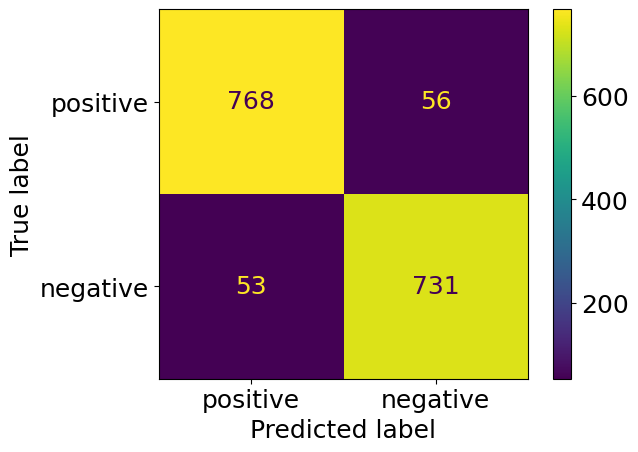

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

plt.rcParams["font.size"] = 18

# 混同行列の作成
confusion_matrix = confusion_matrix(
    y_true=[result["true_label"] for result in results],
    y_pred=[result["pred_label"] for result in results],
    labels=class_label.names
)

# 混同行列の可視化
ConfusionMatrixDisplay(
    confusion_matrix,
    display_labels=class_label.names
).plot()

## 5.3.3 モデルのショートカットに注意

In [12]:
# モデルが誤った事例を収集
failed_results = [
    res for res in results if res["pred_label"] != res["true_label"]
]
# モデルの予測確率が高い順にソート
sorted_failed_results = sorted(
    failed_results, key=lambda x: -x["pred_prob"]
)
# 高い確率で予測しながら誤った事例の上位2件を表示
for top_result in sorted_failed_results[:10]:
    review_text = valid_dataset[top_result["example_id"]]["sentence"]
    print(f"レビュー文: {review_text}")
    print(f"予測: {top_result["pred_label"]}")
    print(f"正解: {top_result["true_label"]}")
    print(f"予測確率: {top_result["pred_prob"]:.4f}")
    print("----------------------------------")

レビュー文: 一月ぶりに湯らっくす行って、10時間も寛いでいまい、寝落ちする以外なにもできない
予測: negative
正解: positive
予測確率: 0.9994
----------------------------------
レビュー文: もうwwww訳がwwwwわからないよwwww
予測: negative
正解: positive
予測確率: 0.9993
----------------------------------
レビュー文: できれば今すぐお線香あげにいきたい
予測: positive
正解: negative
予測確率: 0.9993
----------------------------------
レビュー文: ツイッター早朝部、いくわよ！！ あと諸事情により数人ブロックさせて頂きました…申し訳ない……
予測: negative
正解: positive
予測確率: 0.9993
----------------------------------
レビュー文: 何のこれしき会社員だった頃の辛さに比べれば。まあ種類が違うけど。


予測: negative
正解: positive
予測確率: 0.9991
----------------------------------
レビュー文: というか私のオタク人生に大きな影響を与えすぎたのがクロウ
予測: negative
正解: positive
予測確率: 0.9991
----------------------------------
レビュー文: 自分も周りも含めて全体的に具合悪い時は『重力と恩寵』を読むに限るわね……
予測: negative
正解: positive
予測確率: 0.9990
----------------------------------
レビュー文: この時期はこれだから
予測: positive
正解: negative
予測確率: 0.9987
----------------------------------
レビュー文: 酒はぬるめの 燗がいい 肴は炙った イカでいい←もっといいもの食えよ
予測: positive
正解: negative
予測確率: 0.9987
------------------------------

In [14]:
text="ツイッター早朝部、いくわよ！！ あと諸事情により数人ブロックさせて頂きました…申し訳ない……"
print(sentiment_pipeline(text)[0])

{'label': 'negative', 'score': 0.9992648959159851}


In [15]:
print(sentiment_pipeline(text.replace("申し訳ない", ""))[0])

{'label': 'negative', 'score': 0.989743173122406}


In [ ]:
# 申し訳ない、ブロックを削除してみる
print(sentiment_pipeline(text.replace("申し訳ない", "").replace("ブロック", ""))[0])

{'label': 'positive', 'score': 0.9790592193603516}
